In [1]:
#Show plots inline, and load main getdist plot module and samples class
from __future__ import print_function
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))

import numpy as np
import pandas as pd
import math

import scipy as sp
import scipy.constants as scic
from scipy.interpolate import interp1d
import scipy.interpolate as intr
from scipy.stats import norm
from scipy.optimize import curve_fit
from IPython.display import HTML

import matplotlib
matplotlib.use('Agg')

import matplotlib as mpl
from matplotlib import rc
import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

from mpl_toolkits.axes_grid1 import make_axes_locatable
#from labellines import labelLine, labelLines

from classy import Class
from getdist import plots, MCSamples, loadMCSamples
#from cobaya import load_samples
#from cobaya.samplers.mcmc import plot_progress

#from uncertainties import ufloat, unumpy
#from util import *

%matplotlib inline

%config InlineBackend.figure_format = 'retina'
rc("font", weight="normal"); rc("font", size="20")
# Set the global font family to serif
mpl.rcParams['font.family'] = 'serif'
# Specify "Times New Roman" as the preferred serif font
#mpl.rcParams['font.serif'] = ['Times New Roman']

#rc("font", family='Times New Roman'); rc("font", style='italic')
rc("axes"); rc("axes",labelsize="18"); rc("xtick",labelsize="14"); rc("ytick",labelsize="14")#, labelweight="bold"
#plt.rcParams['text.usetex']=True
#plt.rcParams['text.latex.preamble'] = [r'\usepackage{sfmath} \boldmath']
font = {'family': 'Times New Roman', #'serif',#'monospace',
        'color': 'black',
        'weight': 'normal',
        'size': 16,
        'style':'italic',
        }

In [2]:
from classy import Class

In [3]:
params_cmn = {'gauge': 'newtonian',
              'nonlinear_min_k_max': 25,
              'N_ncdm': 1,
              'N_ur': 2.046,
              'non linear': 'hmcode',
              'hmcode_version': 2020,
              'output' : 'tCl,pCl,lCl,mPk',
              'l_max_scalars': 9000, 
              'lensing': 'yes',
            }

In [4]:
params_lcdm =  {'Omega_fld': 0,
                'Omega_scf': 0}
params_cmn.update(params_lcdm)

In [5]:
%%time
Model_LCDM = Class()
Model_LCDM.set(params_cmn)
Model_LCDM.compute()
BackQunt_LCDM = Model_LCDM.get_background()

CPU times: user 3min 9s, sys: 10.4 s, total: 3min 19s
Wall time: 11.8 s


In [6]:
# ── New model: b = -a, kappa parameterization ──
# Sampled params
f_x     = -0.1                # tilde{f}_x: fractional exotic contribution at z_c
z_c_exo = 35           # window center
kappa   = 0.2                 # e-fold width (fixed)

# Derived params
sigma_z_exo = kappa * (1.0 + z_c_exo)   # redshift width from kappa

# E^2_LCDM at z_c (Planck fiducial)
Omega_m  = 0.31
Omega_r  = 9.24e-5
Omega_L  = 1.0 - Omega_m - Omega_r
E2_LCDM  = Omega_m*(1+z_c_exo)**3 + Omega_r*(1+z_c_exo)**4 + Omega_L

# a_exo from f_x
a_exo = f_x * (1.0 + z_c_exo) * E2_LCDM
b_exo = -a_exo                            # b = -a model

# Derived for reporting
Omega_x0 = a_exo * np.exp(-z_c_exo**2 / (2.0 * sigma_z_exo**2))

print(f"z_c     = {z_c_exo}")
print(f"kappa   = {kappa}")
print(f"sigma_z = {sigma_z_exo:.2f}")
print(f"f_x     = {f_x}")
print(f"a_exo   = {a_exo:.1f}")
print(f"b_exo   = {b_exo:.1f}")
print(f"Omega_x0= {Omega_x0:.4e}")
print(f"E2_LCDM = {E2_LCDM:.1f}")

z_c     = 35
kappa   = 0.2
sigma_z = 7.20
f_x     = -0.1
a_exo   = -52629.3
b_exo   = 52629.3
Omega_x0= -3.8900e-01
E2_LCDM = 14619.2


In [7]:
# (1+z_cmb)/z_cmb

In [8]:
# ── Physicality bound: E^2 >= (1-f_floor) * E^2_LCDM ──
f_floor = 0.2   # max allowed fractional suppression

# With b=-a: amp(z) = a/(1+z), so Delta E^2 = a*G(z)/(1+z)
# Worst-case z is slightly below z_c (Gaussian * 1/(1+z) peaks there)
# Conservative single-point bound at z_c (where G=1):
#   a / (1+z_c) >= -f_floor * E^2_LCDM(z_c)
a_limit   = -f_floor * (1.0 + z_c_exo) * E2_LCDM
f_x_limit = -f_floor   # by construction

print(f"a_exo  must be >= {a_limit:.1f}")
print(f"f_x    must be >= {f_x_limit}")
print(f"(current a_exo = {a_exo:.1f}, f_x = {f_x})")

a_exo  must be >= -105258.6
f_x    must be >= -0.2
(current a_exo = -52629.3, f_x = -0.1)


In [9]:
params_exo = {'Omega_fld': 0,
              'Omega_scf': 0,
              'a_exo': a_exo,
              'b_exo': b_exo,
              'z_c_exo': z_c_exo,
              'sigma_z_exo': sigma_z_exo,
             }
params_cmn.update(params_exo)

In [10]:
%%time
Model = Class()
Model.set(params_cmn)
Model.compute()
BackQunt = Model.get_background()

CPU times: user 3min 8s, sys: 13.5 s, total: 3min 21s
Wall time: 12.3 s


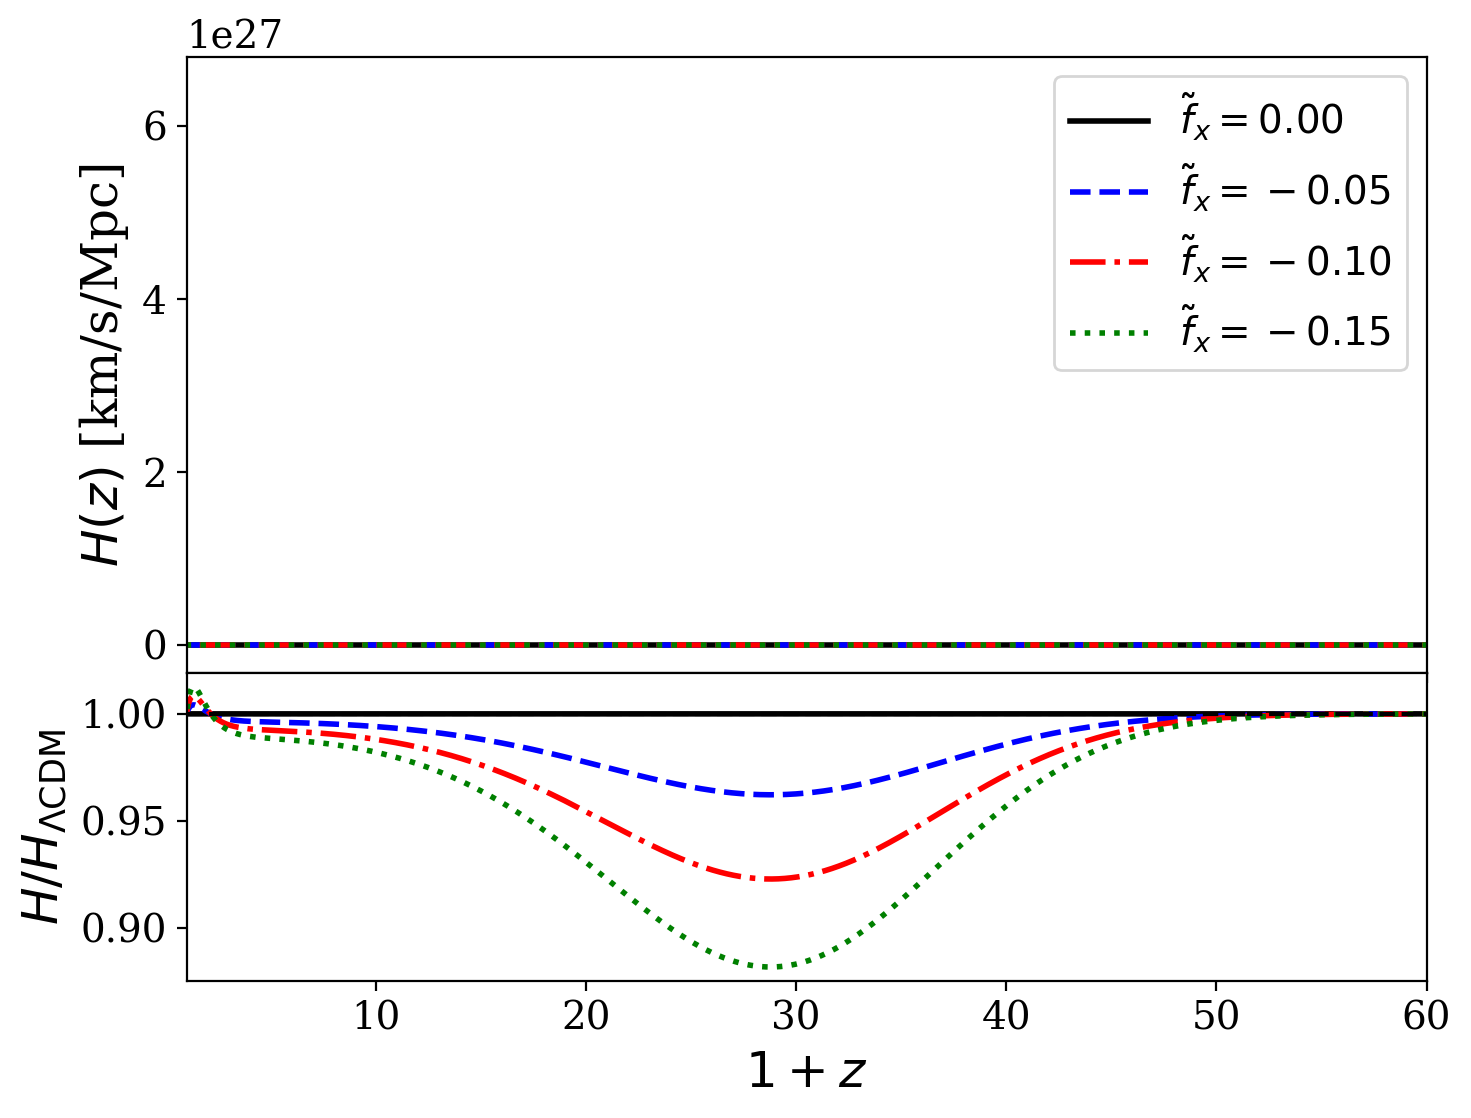

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=(2, 1))
plt.subplots_adjust(hspace=0.0)

f_x_arr = np.array([0.0, -0.05, -0.1, -0.15])
lstyls  = ['-', '--', '-.', ':']
colors  = ['k', 'b', 'r', 'g']
labels  = [rf'$\tilde{{f}}_x = {f:.2f}$' for f in f_x_arr]

for i, fx in enumerate(f_x_arr):
    a_i = fx * (1.0 + z_c_exo) * E2_LCDM
    b_i = -a_i
    sigma_i = kappa * (1.0 + z_c_exo)
    params_exo.update({'a_exo': a_i, 'b_exo': b_i, 'sigma_z_exo': sigma_i})
    params_cmn.update(params_exo)
    Model.set(params_cmn)
    Model.compute()
    BQ = Model.get_background()
    ax1.plot(1 + BQ['z'], 1e-3*scic.c*BQ['H [1/Mpc]'],
             ls=lstyls[i], lw=2., c=colors[i], label=labels[i])
    ax2.plot(1 + BQ['z'],
             1e-3*scic.c*BQ['H [1/Mpc]'] / (1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]']),
             ls=lstyls[i], lw=2., c=colors[i])
    Model.struct_cleanup()

ax2.axhline(1.0, ls='--', lw=1.5, c='k')
# ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.legend(fontsize=14)
ax2.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$H(z)$ [km/s/Mpc]', fontsize=18)
ax2.set_ylabel(r'$H/H_{\Lambda\mathrm{CDM}}$', fontsize=18)
ax1.set_xlim(1, 60)
plt.show()

In [33]:
# --- Vary kappa (fixed f_x and z_c) ---

kap_arr = np.array([0.05, 0.10, 0.15, 0.20, 0.30])

fx = -0.2          # fixed
z_c_exo = 35.0     # fixed

plt.figure(figsize=(7,5))

for kappa in kap_arr:

    a_i = fx * (1.0 + z_c_exo) * E2_LCDM
    b_i = -a_i
    sigma_i = kappa * (1.0 + z_c_exo)

    params_exo = {
        **params_cmn,
        'a_exo': a_i,
        'b_exo': b_i,
        'z_c_exo': z_c_exo,
        'sigma_z_exo': sigma_i,
    }

    Model = Class()
    Model.set(params_exo)
    Model.compute()

    bg = Model.get_background()

    z = bg['z']
    H = bg['H [1/Mpc]']

    plt.plot(
        z,
        H / H_LCDM(z),
        label=fr'$\kappa={kappa:.2f}$'
    )

    Model.struct_cleanup()
    Model.empty()

plt.xscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$H/H_{\Lambda{\rm CDM}}$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

NameError: name 'H_LCDM' is not defined

<Figure size 700x500 with 0 Axes>

In [ ]:
# --- Vary z_c (fixed f_x and kappa) ---

zc_arr = np.array([10, 20, 35, 50, 100])

fx = -0.2        # fixed
kappa = 0.10     # fixed

plt.figure(figsize=(7,5))

for z_c_exo in zc_arr:

    a_i = fx * (1.0 + z_c_exo) * E2_LCDM
    b_i = -a_i
    sigma_i = kappa * (1.0 + z_c_exo)

    params_exo = {
        **params_cmn,
        'a_exo': a_i,
        'b_exo': b_i,
        'z_c_exo': z_c_exo,
        'sigma_z_exo': sigma_i,
    }

    Model = Class()
    Model.set(params_exo)
    Model.compute()

    bg = Model.get_background()

    z = bg['z']
    H = bg['H [1/Mpc]']

    plt.plot(
        z,
        H / H_LCDM(z),
        label=fr'$z_c={z_c_exo}$'
    )

    Model.struct_cleanup()
    Model.empty()

plt.xscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$H/H_{\Lambda{\rm CDM}}$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

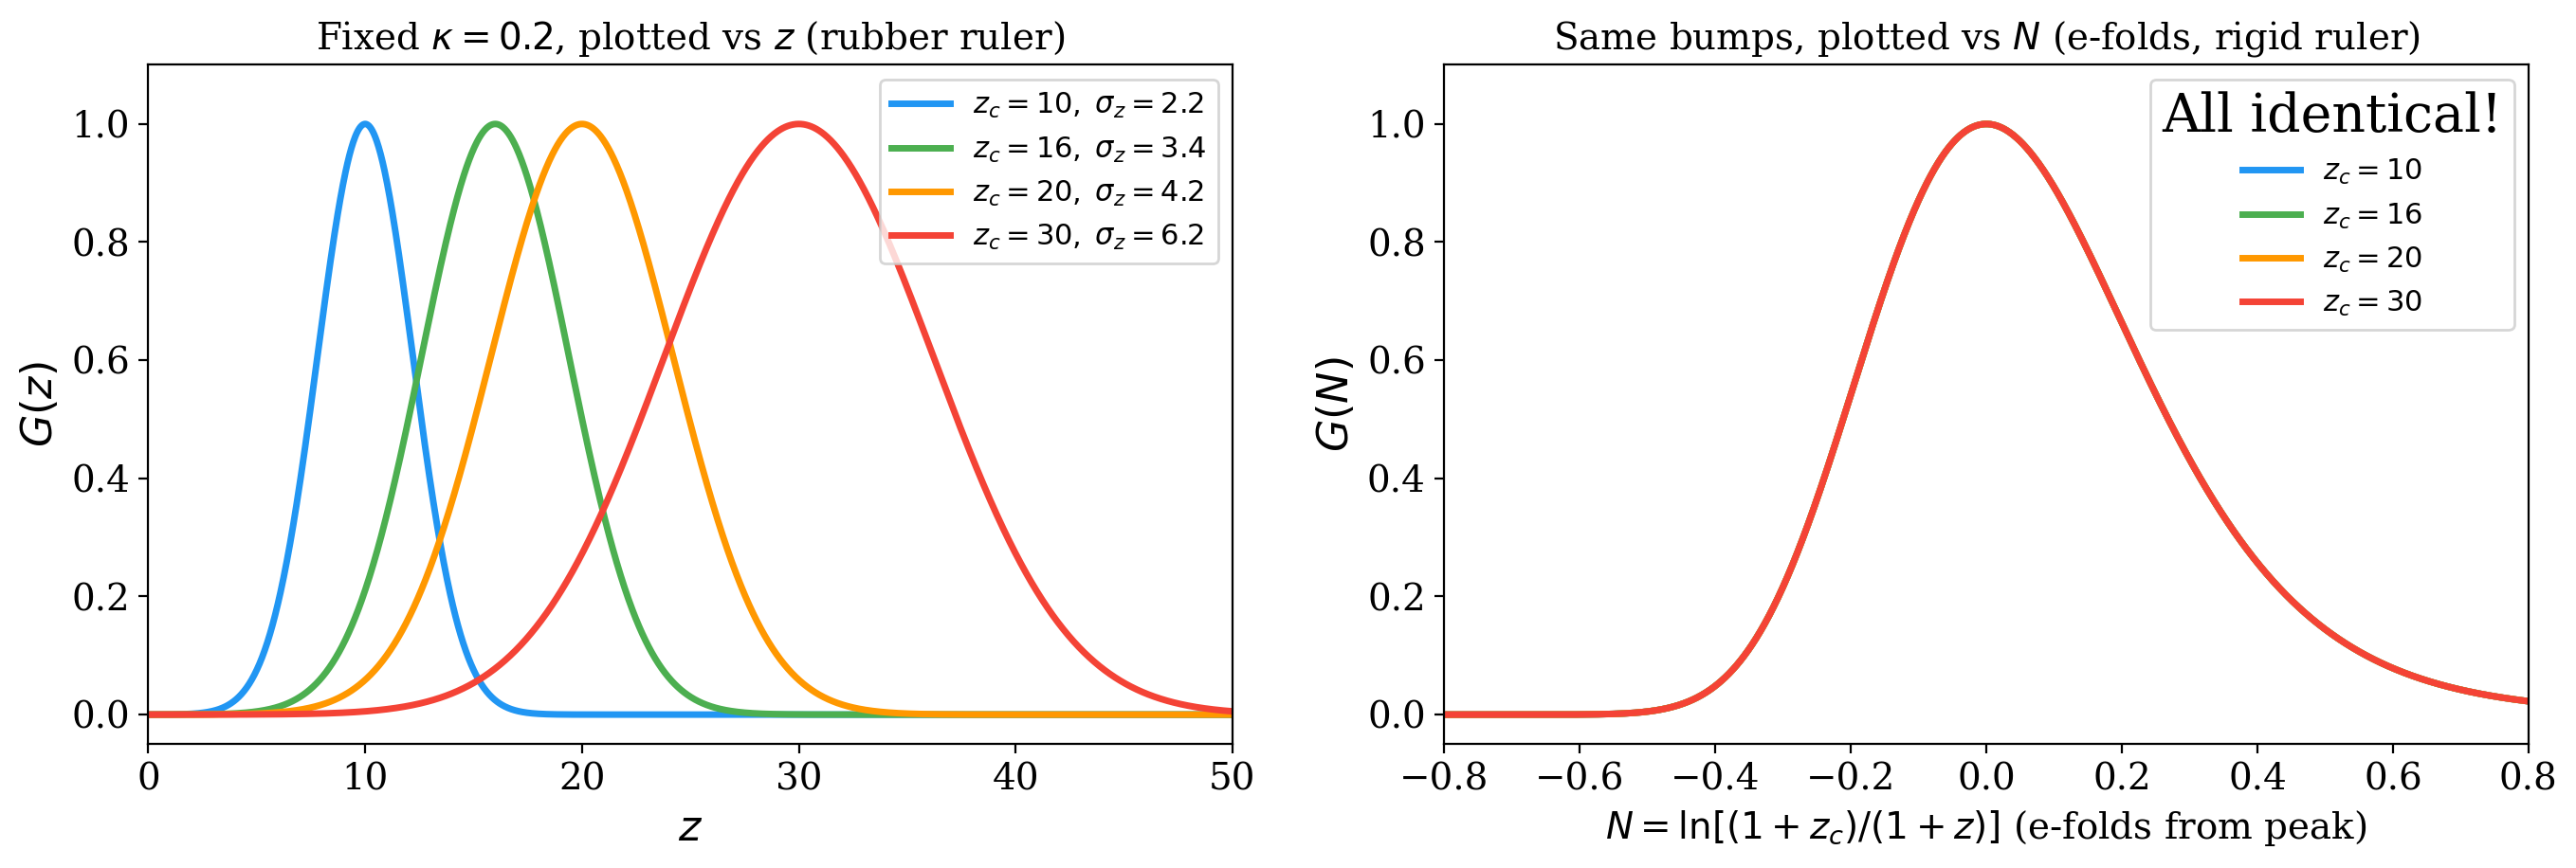

In [12]:
# ── kappa demo: same bump at different z_c ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

z_arr = np.linspace(0, 150 , 5000)
zc_list = [10, 16, 20, 30, 50]
colors_zc = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# Left panel: G(z) vs z — looks different (rubber ruler)
ax = axes[0]
ax.set_title(r'Fixed $\kappa=0.2$, plotted vs $z$ (rubber ruler)', fontsize=14)
for zc, col in zip(zc_list, colors_zc):
    sig = kappa * (1.0 + zc)
    G = np.exp(-(z_arr - zc)**2 / (2.0 * sig**2))
    ax.plot(z_arr, G, lw=2.5, c=col, label=rf'$z_c={zc},\;\sigma_z={sig:.1f}$')
ax.set_xlabel(r'$z$', fontsize=16)
ax.set_ylabel(r'$G(z)$', fontsize=16)
ax.legend(fontsize=11)
ax.set_xlim(0, 50)
ax.set_ylim(-0.05, 1.1)

# Right panel: G(N) vs N — all identical (rigid ruler)
ax = axes[1]
ax.set_title(r'Same bumps, plotted vs $N$ (e-folds, rigid ruler)', fontsize=14)
N_arr = np.linspace(-0.8, 0.8, 2000)
for zc, col in zip(zc_list, colors_zc):
    # G(N) = exp(-(e^{-N} - 1)^2 / (2 kappa^2))  — no z_c
    GN = np.exp(-(np.exp(-N_arr) - 1)**2 / (2.0 * kappa**2))
    ax.plot(N_arr, GN, lw=2.5, c=col, label=rf'$z_c={zc}$')
ax.set_xlabel(r'$N = \ln[(1+z_c)/(1+z)]$ (e-folds from peak)', fontsize=14)
ax.set_ylabel(r'$G(N)$', fontsize=16)
ax.legend(fontsize=11, title='All identical!')
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

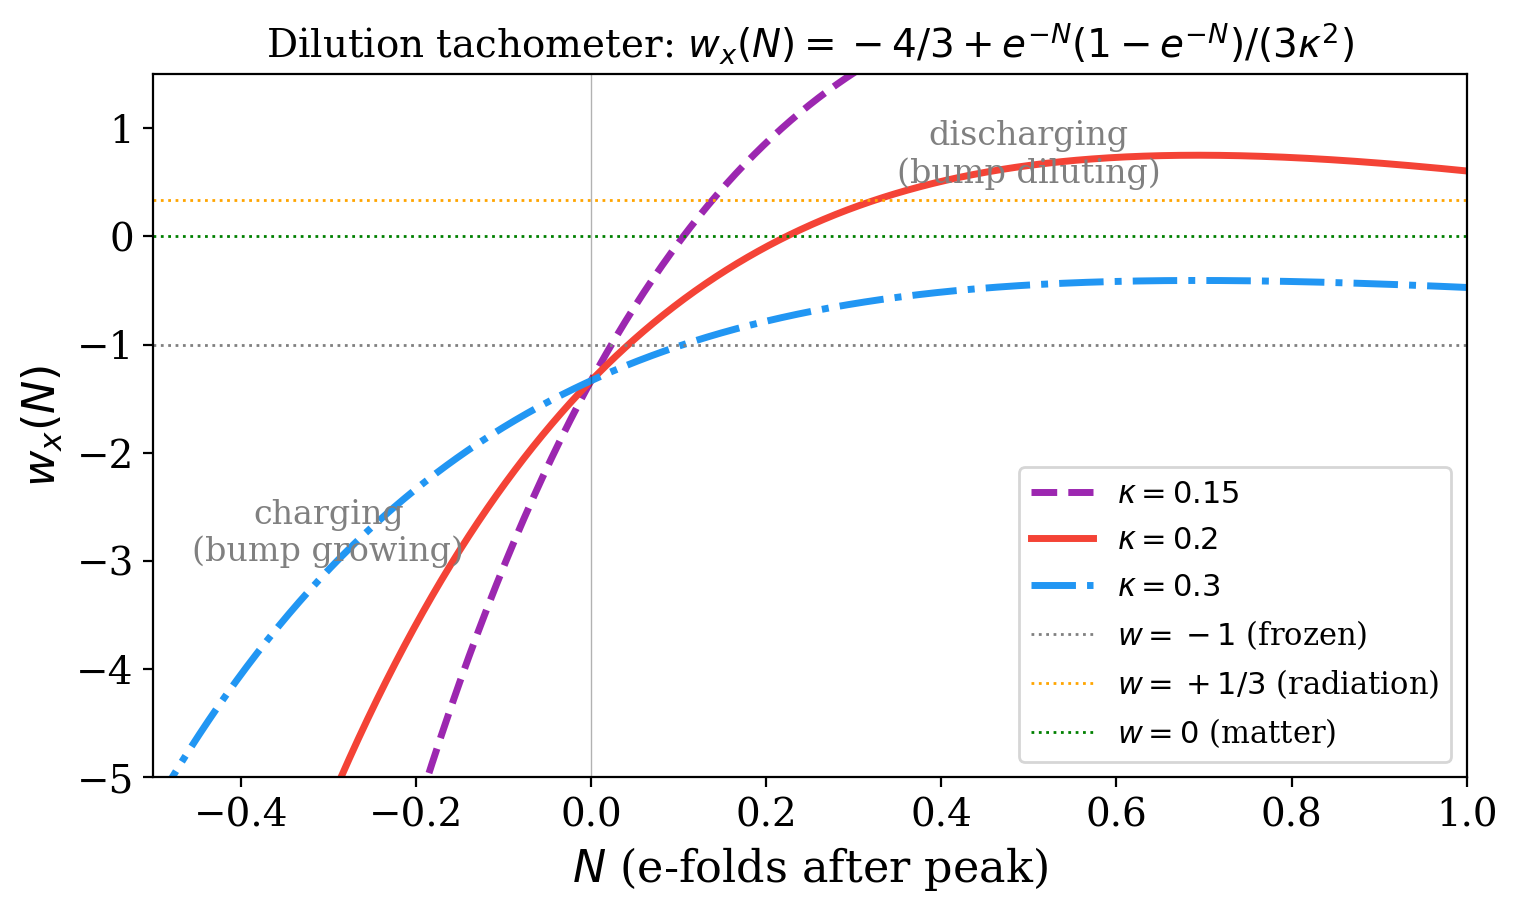

In [13]:
# ── w_x(N) tachometer ──
fig, ax = plt.subplots(figsize=(8, 5))
N_arr = np.linspace(-0.5, 1.0, 1000)

for k, col, ls in [(0.15, '#9C27B0', '--'), (0.2, '#F44336', '-'), (0.3, '#2196F3', '-.')]:
    wx = -4.0/3.0 + np.exp(-N_arr)*(1.0 - np.exp(-N_arr)) / (3.0*k**2)
    ax.plot(N_arr, wx, lw=2.5, c=col, ls=ls, label=rf'$\kappa={k}$')

ax.axhline(-1.0, ls=':', c='grey', lw=1, label=r'$w=-1$ (frozen)')
ax.axhline(1./3, ls=':', c='orange', lw=1, label=r'$w=+1/3$ (radiation)')
ax.axhline(0.0, ls=':', c='green', lw=1, label=r'$w=0$ (matter)')
ax.axvline(0.0, ls='-', c='k', lw=0.5, alpha=0.3)

ax.set_xlabel(r'$N$ (e-folds after peak)', fontsize=16)
ax.set_ylabel(r'$w_x(N)$', fontsize=16)
ax.set_title(r'Dilution tachometer: $w_x(N) = -4/3 + e^{-N}(1-e^{-N})/(3\kappa^2)$', fontsize=14)
ax.set_xlim(-0.5, 1.0)
ax.set_ylim(-5, 1.5)
ax.legend(fontsize=11, loc='lower right')
ax.annotate('charging\n(bump growing)', xy=(-0.3, -3), fontsize=12, color='grey', ha='center')
ax.annotate('discharging\n(bump diluting)', xy=(0.5, 0.5), fontsize=12, color='grey', ha='center')
plt.tight_layout()
plt.show()

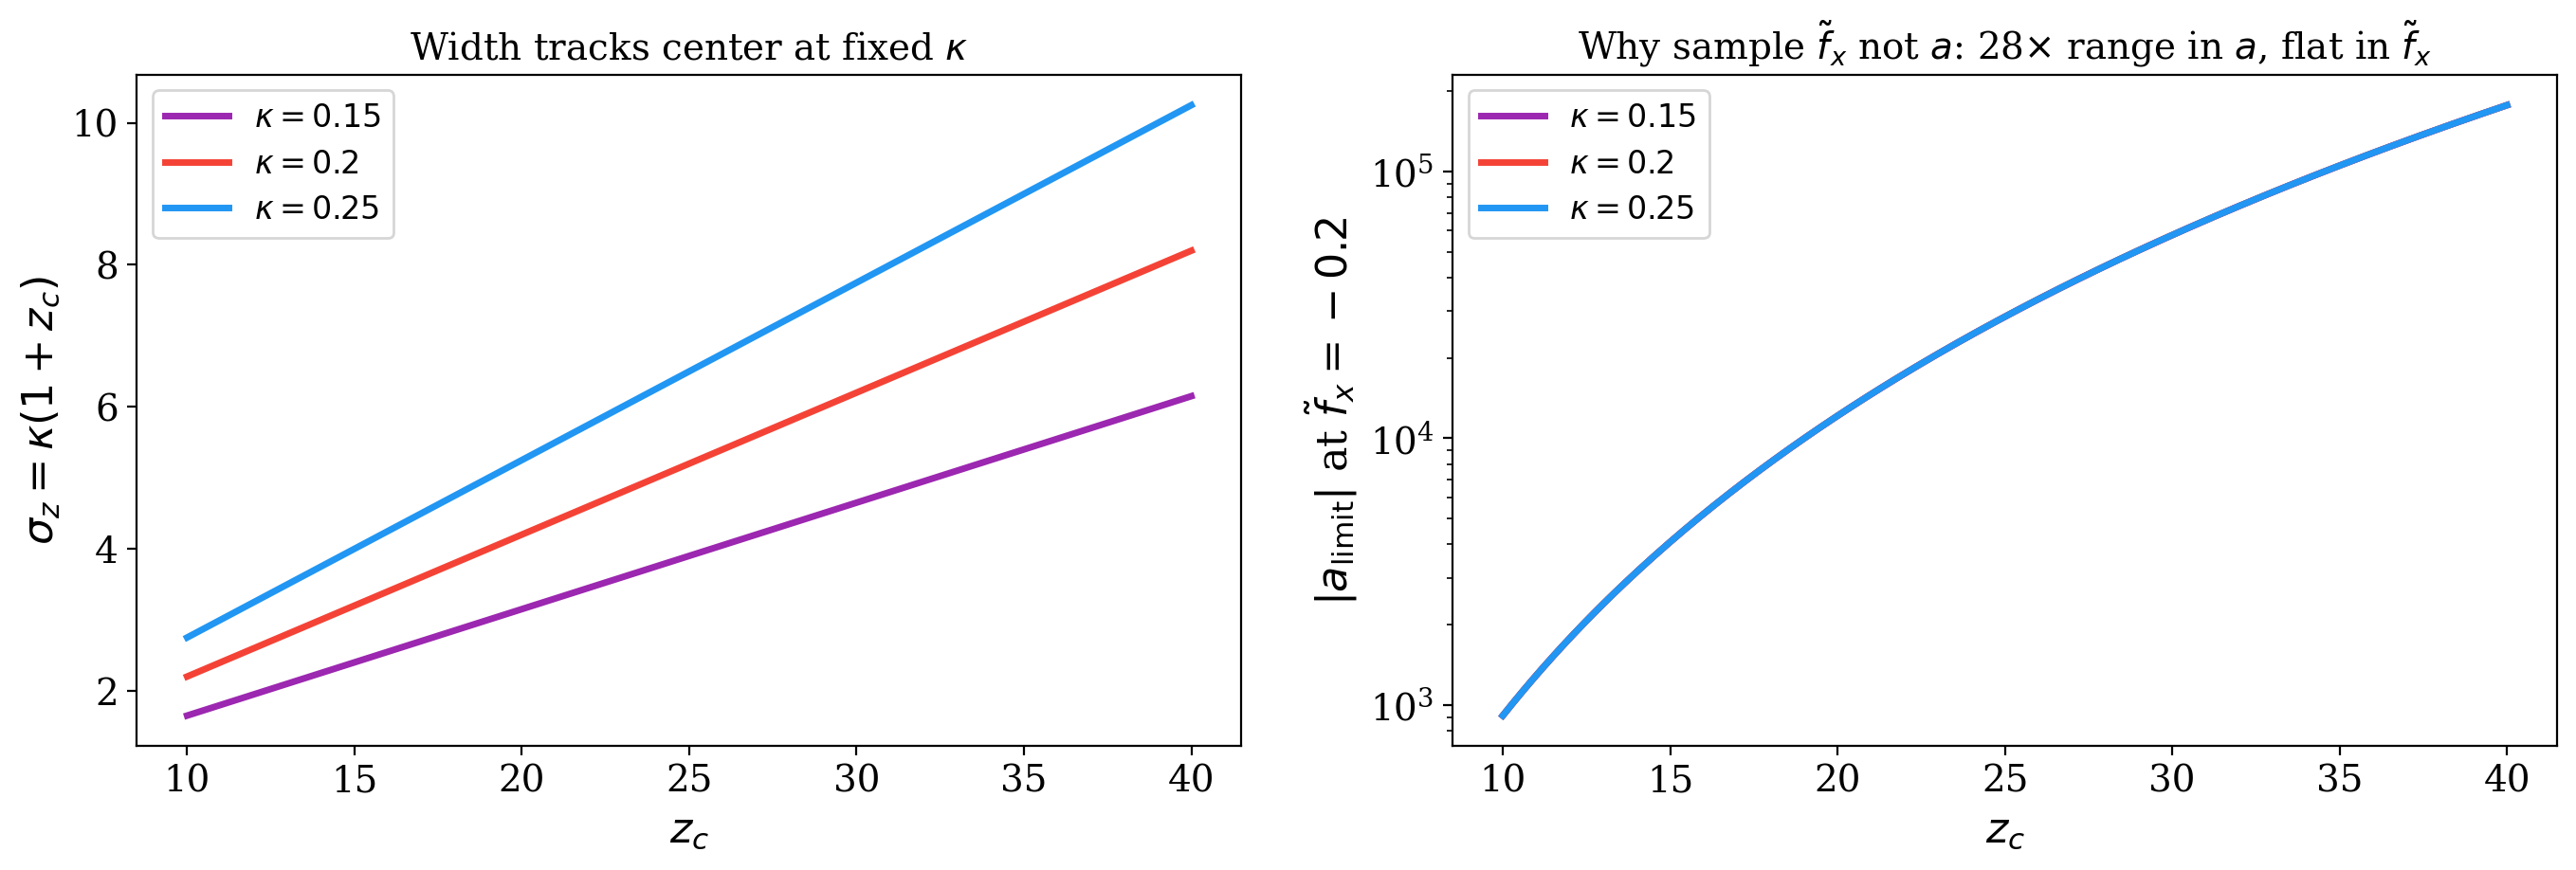

In [14]:
# ── sigma_z vs z_c at fixed kappa, and physicality bound on f_x ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

zc_range = np.linspace(10, 40, 200)

# Left: sigma_z vs z_c
for k, col in [(0.15, '#9C27B0'), (0.2, '#F44336'), (0.25, '#2196F3')]:
    ax1.plot(zc_range, k*(1+zc_range), lw=2.5, c=col, label=rf'$\kappa={k}$')
ax1.set_xlabel(r'$z_c$', fontsize=16)
ax1.set_ylabel(r'$\sigma_z = \kappa(1+z_c)$', fontsize=16)
ax1.legend(fontsize=12)
ax1.set_title(r'Width tracks center at fixed $\kappa$', fontsize=14)

# Right: a_limit vs z_c (physicality f_x >= -0.2)
for k, col in [(0.15, '#9C27B0'), (0.2, '#F44336'), (0.25, '#2196F3')]:
    E2 = Omega_m*(1+zc_range)**3 + Omega_r*(1+zc_range)**4 + Omega_L
    a_lim = -0.2 * (1+zc_range) * E2
    ax2.semilogy(zc_range, np.abs(a_lim), lw=2.5, c=col, label=rf'$\kappa={k}$')
ax2.set_xlabel(r'$z_c$', fontsize=16)
ax2.set_ylabel(r'$|a_{\rm limit}|$ at $\tilde{f}_x = -0.2$', fontsize=16)
ax2.legend(fontsize=12)
ax2.set_title(r'Why sample $\tilde{f}_x$ not $a$: 28$\times$ range in $a$, flat in $\tilde{f}_x$', fontsize=14)

plt.tight_layout()
plt.show()

In [15]:
def rho_x(z, a, b, z_c, sgm):
    return (a + b * z/(1 + z)) * np.exp(-(z-z_c)**2/(2 * sgm**2))
def rho_x_nogauss(z, a, b):
    return a + b * z/(1 + z)

In [16]:
zthr = plt.linspace(0,1e3, 10000)

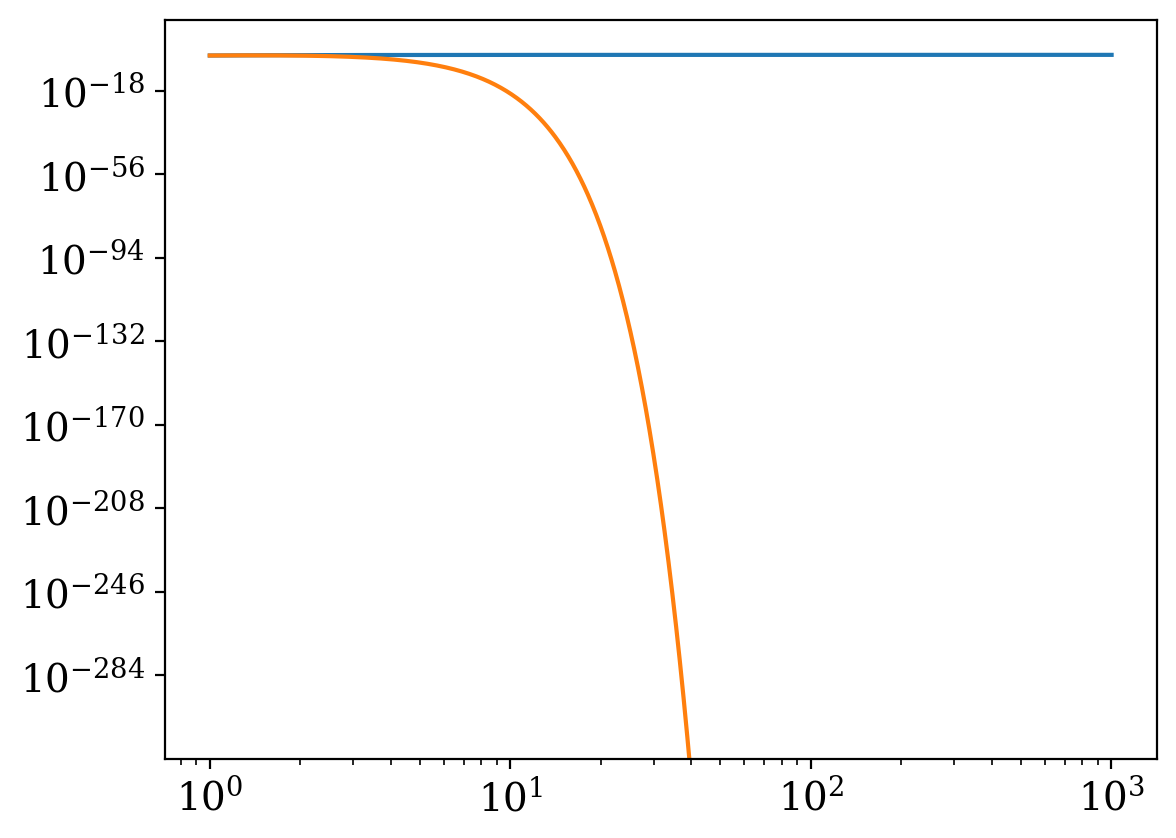

In [17]:
#plt.loglog(1+zthr, rho_x(zthr, 0.01, 0.1, 10, 3))
plt.loglog(1+zthr, rho_x_nogauss(zthr, 1e-2, 1e-2))
plt.loglog(1+zthr, rho_x(zthr, 1e-2, 1e-2, 0.0, 1.0))

(0.0, 20.0)

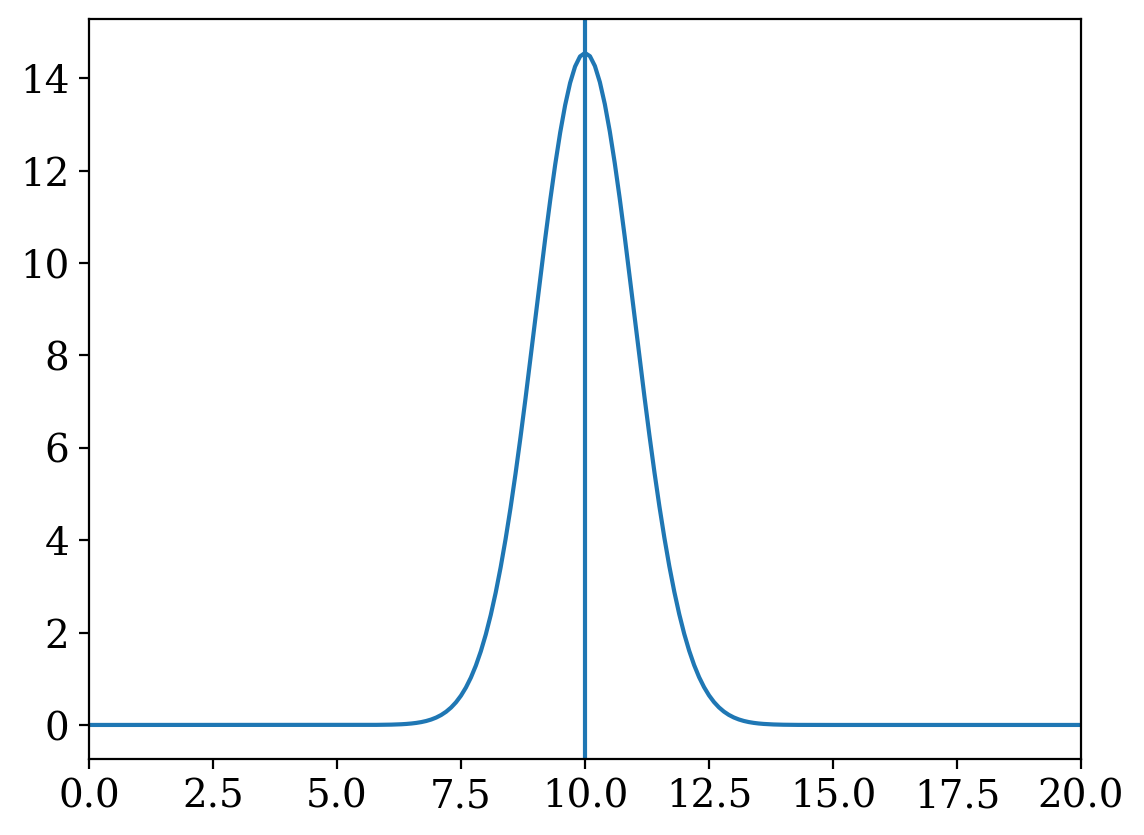

In [18]:
plt.plot(zthr, (10 + 5 * zthr/(1+zthr)) * np.exp(-0.5 * (zthr-10.0)**2/(1**2)))
plt.axvline(10.0)
plt.xlim(0., 20)

In [19]:
def rho_x(z,z_c, sgm):
    return np.exp(-(z-z_c)**2/(2 * sgm**2))

(0.0, 20.0)

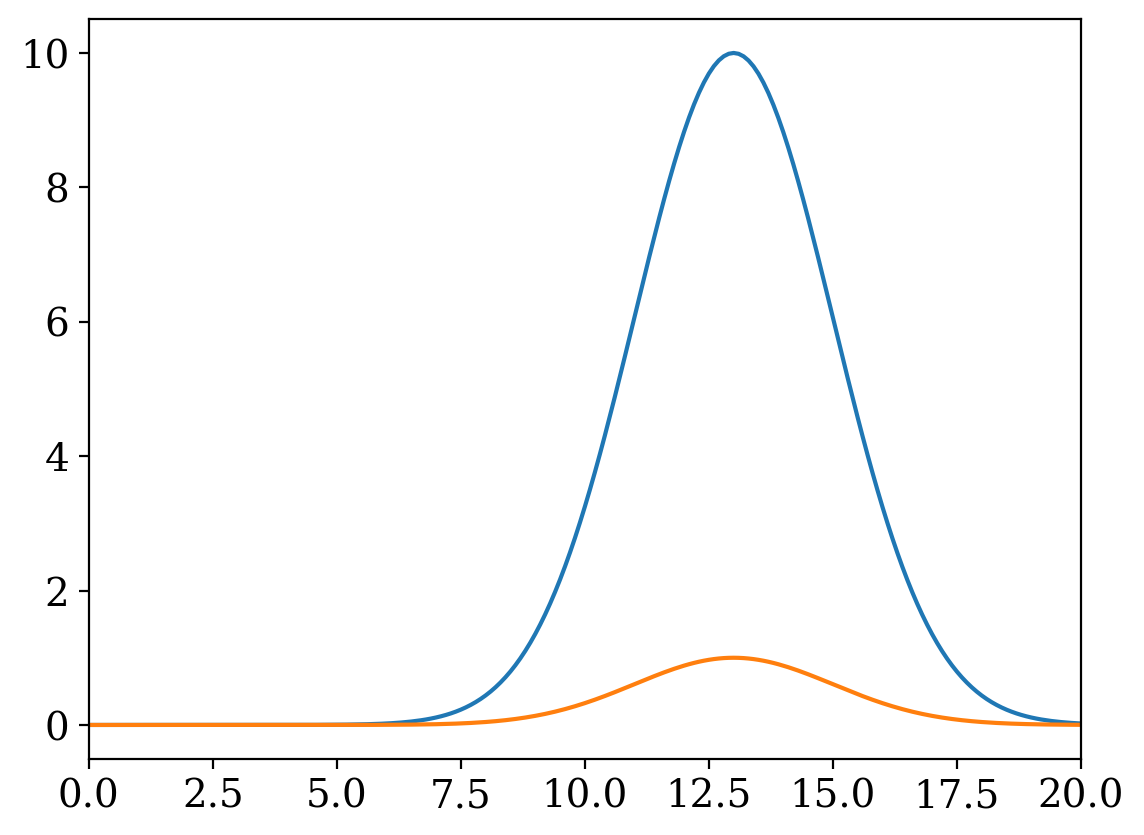

In [20]:
plt.plot(zthr, 10 * rho_x(zthr,13., 2.0))
plt.plot(zthr, 1 * rho_x(zthr,13., 2.0))
plt.xlim(0.0, 20.0)

## Example of classy

In [21]:
from classy import Class

In [22]:
Model_LCDM  = Class()

In [23]:
parm = {'H0':70.0, 'Omega_cdm':0.3}
Model_LCDM.set(parm)
Model_LCDM.compute()

In [24]:
Model_LCDM.luminosity_distance

<bound method Class.luminosity_distance of <classy._classy.Class object at 0xe0c08f0>>

/tmp/ipykernel_80819/2351554186.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(1+z, 5.0*np.log10(Model_LCDM.luminosity_distance(z)) + 25)


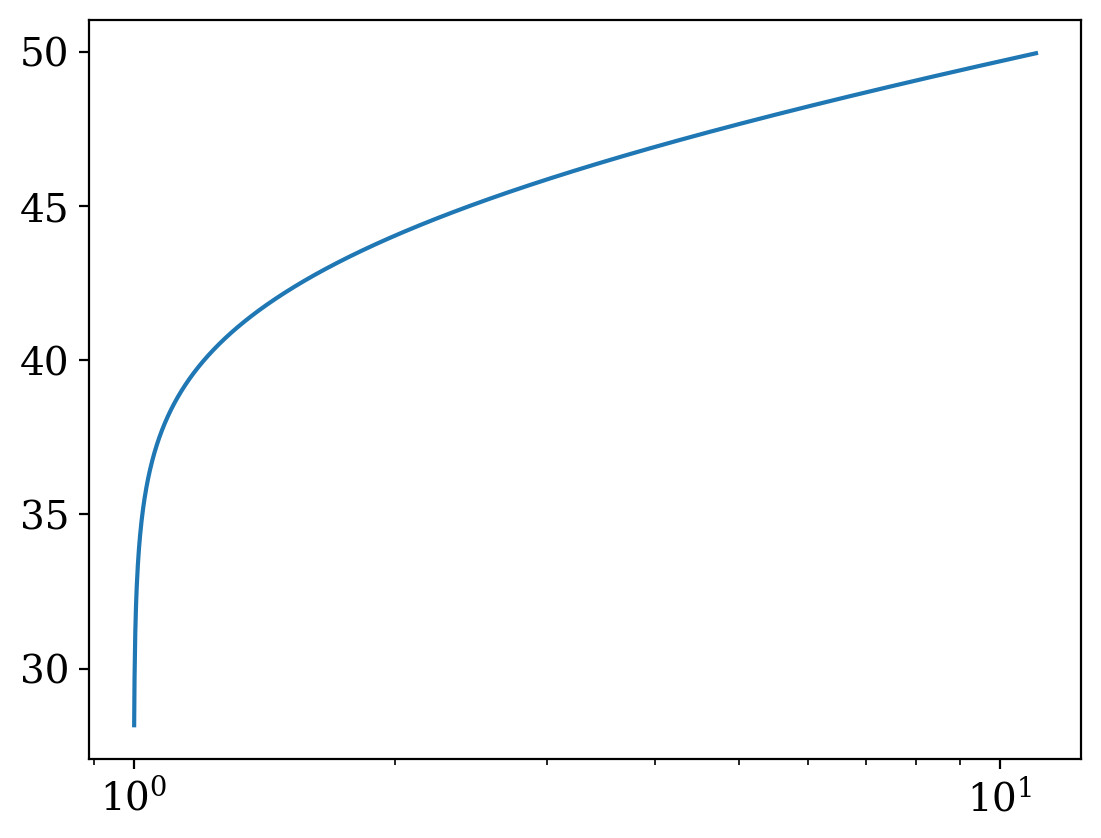

In [25]:
import scipy.constants as sc
z = np.linspace(0, 1e1, 10000)
plt.figure()
plt.semilogx(1+z, 5.0*np.log10(Model_LCDM.luminosity_distance(z)) + 25)
plt.show()